# **Diplomado IA: Inteligencia Artificial II - Métodos de Profundización**. <br> Práctico: Meta Aprendizaje (Parte 1)
---
---

**Profesor:** Pablo Messina (pamessina@uc.cl)


# Introducción

Este laboratorio está basado fuertemente en [learn2learn](https://learn2learn.net/examples/vision/), una librería open-source para investigación en meta-learning.

En particular, veremos el uso de dos métodos concretos:

1) Model-Agnostic Meta-Learning (MAML): https://arxiv.org/abs/1703.03400

2) Prototypical Networks for Few-shot Learning: https://arxiv.org/abs/1703.05175

Los datasets que usaremos son Omniglot y Mini-ImageNet, y los códigos consultados para la confección de este laboratorio son los siguientes:

- https://github.com/learnables/learn2learn/blob/master/examples/vision/maml_omniglot.py
- https://github.com/learnables/learn2learn/blob/master/examples/vision/maml_miniimagenet.py
- https://github.com/learnables/learn2learn/blob/master/examples/vision/protonet_miniimagenet.py


# Instalando e importando librerías a usar

Instalamos learn2learn desde GitHub primero debido al siguiente issue: https://github.com/learnables/learn2learn/issues/433

In [1]:
!git clone https://github.com/learnables/learn2learn.git
%cd learn2learn
!pip install -e .

fatal: destination path 'learn2learn' already exists and is not an empty directory.
/content/learn2learn
Obtaining file:///content/learn2learn
  Preparing metadata (setup.py) ... done
  Attempting uninstall: learn2learn
    Found existing installation: learn2learn 0.2.1
    Uninstalling learn2learn-0.2.1:
      Successfully uninstalled learn2learn-0.2.1
  Running setup.py develop for learn2learn


Luego Colab debería pedirles reiniciar el entorno de ejecución. Reinician, e immediatamente después instalan learn2learn con el comando típico !pip install learn2learn:

In [2]:
!pip install learn2learn

Importamos librerías a usar

In [3]:
import gc
import random
import numpy as np
import learn2learn as l2l
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch import nn, optim
from typing import List, Tuple
from IPython.display import clear_output

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

Usamos cuda

In [4]:
use_cuda = torch.cuda.is_available() and True
device = torch.device("cuda" if use_cuda else "cpu")
device

device(type='cuda')

# Cargamos datasets: Omniglot y Mini-ImageNet

Funciones para visualizar tareas de ambos datasets

In [5]:
def visualize_task_omniglot(
    batch: Tuple[torch.Tensor, torch.Tensor], shot: int, ways: int
) -> None:
    """
    Visualize a sampled Omniglot task by splitting into adaptation and evaluation sets.

    Args:
        batch: A tuple (data, labels) where
            - data: Tensor of shape (N, 1, H, W), grayscale Omniglot images.
            - labels: Tensor of shape (N,), class labels (not used here).
        shot: Number of examples per class for adaptation.
        ways: Number of classes per task.

    Returns:
        None. Displays matplotlib figures with adaptation and evaluation images.
    """
    data = batch[0]

    # Create boolean masks for adaptation and evaluation sets
    adaptation_indices = np.zeros(data.size(0), dtype=bool)
    adaptation_indices[np.arange(shot * ways) * 2] = True
    evaluation_indices = torch.from_numpy(~adaptation_indices)
    adaptation_indices = torch.from_numpy(adaptation_indices)

    # Split data into adaptation and evaluation sets
    adaptation_data = data[adaptation_indices]
    evaluation_data = data[evaluation_indices]

    # --- Plot adaptation data ---
    print("Adaptation data:")
    n = len(adaptation_data)
    f, axarr = plt.subplots(1, n, figsize=(10, 10))
    for i in range(n):
        axarr[i].imshow(adaptation_data[i, 0], cmap="gray")
    np.vectorize(lambda ax: ax.axis("off"))(axarr)
    plt.show()

    # --- Plot evaluation data ---
    print("Evaluation data:")
    n = len(evaluation_data)
    f, axarr = plt.subplots(1, n, figsize=(10, 10))
    for i in range(n):
        axarr[i].imshow(evaluation_data[i, 0], cmap="gray")
    np.vectorize(lambda ax: ax.axis("off"))(axarr)
    plt.show()


def visualize_task_miniimagenet(
    batch: Tuple[torch.Tensor, torch.Tensor], shots: int, ways: int
) -> None:
    """
    Visualize a sampled Mini-ImageNet task by splitting into adaptation and evaluation sets.

    Args:
        batch: A tuple (data, labels) where
            - data: Tensor of shape (N, 3, H, W), RGB Mini-ImageNet images.
            - labels: Tensor of shape (N,), class labels (not used here).
        shots: Number of examples per class for adaptation.
        ways: Number of classes per task.

    Returns:
        None. Displays matplotlib figures with adaptation and evaluation images.
    """
    data = batch[0]

    # Create boolean masks for adaptation and evaluation sets
    adaptation_indices = np.zeros(data.size(0), dtype=bool)
    adaptation_indices[np.arange(shots * ways) * 2] = True
    evaluation_indices = torch.from_numpy(~adaptation_indices)
    adaptation_indices = torch.from_numpy(adaptation_indices)

    # Split data into adaptation and evaluation sets
    adaptation_data = data[adaptation_indices]
    evaluation_data = data[evaluation_indices]

    # --- Plot adaptation data ---
    print("Adaptation data:")
    n = len(adaptation_data)
    f, axarr = plt.subplots(1, n, figsize=(15, 15))
    for i in range(n):
        # Permute channels to (H, W, C) and normalize to [0, 1]
        axarr[i].imshow(adaptation_data[i].permute(1, 2, 0) / 255.0)
    np.vectorize(lambda ax: ax.axis("off"))(axarr)
    plt.show()

    # --- Plot evaluation data ---
    print("Evaluation data:")
    n = len(evaluation_data)
    f, axarr = plt.subplots(1, n, figsize=(15, 15))
    for i in range(n):
        axarr[i].imshow(evaluation_data[i].permute(1, 2, 0) / 255.0)
    np.vectorize(lambda ax: ax.axis("off"))(axarr)
    plt.show()

Definimos WAYS y SHOTS que usaremos

In [6]:
WAYS = 4
SHOTS = 1

## Cargamos e inspeccionamos Omniglot

In [7]:
tasksets_omniglot = l2l.vision.benchmarks.get_tasksets('omniglot',
                                                       train_ways=WAYS,
                                                       train_samples=2*SHOTS,
                                                       test_ways=WAYS,
                                                       test_samples=2*SHOTS,
                                                       num_tasks=10000,
                                                       root='~/data',
)

Adaptation data:


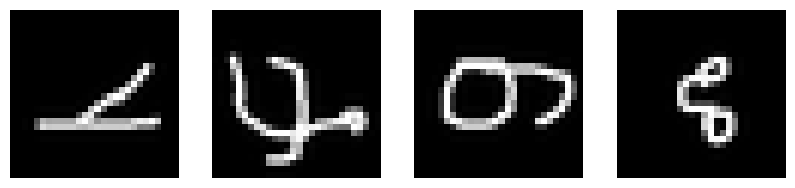

Evaluation data:


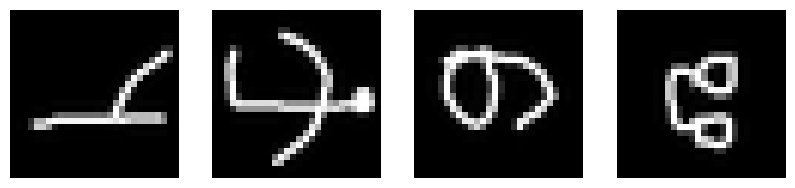

In [8]:
visualize_task_omniglot(tasksets_omniglot.train.sample(), SHOTS, WAYS)

Adaptation data:


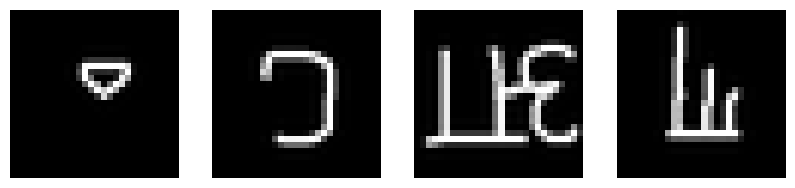

Evaluation data:


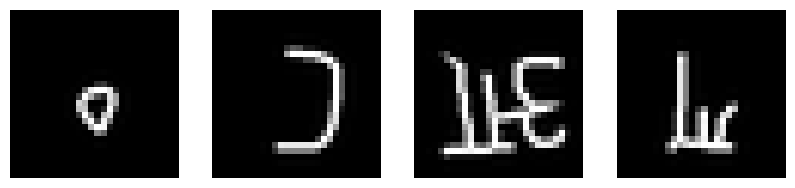

In [9]:
visualize_task_omniglot(tasksets_omniglot.validation.sample(), SHOTS, WAYS)

Adaptation data:


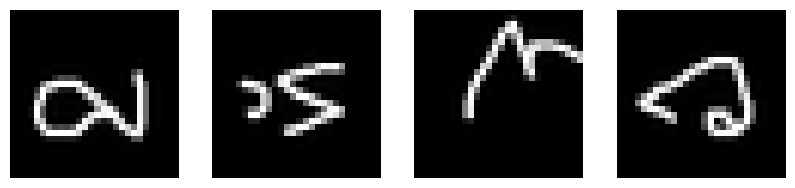

Evaluation data:


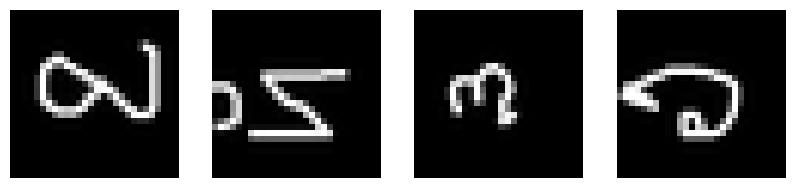

In [10]:
visualize_task_omniglot(tasksets_omniglot.test.sample(), SHOTS, WAYS)

## Cargamos e inspeccionamos Mini-ImageNet

In [14]:
# Si la descarga de archivos falla, los siguientes comandos se pueden correr para descargar los archivos manualmente
!wget -O ~/data/mini-imagenet-cache-validation.pkl https://www.dropbox.com/s/ip1b7se3gij3r1b/mini-imagenet-cache-validation.pkl?dl=1
!wget -O ~/data/mini-imagenet-cache-train.pkl https://www.dropbox.com/s/9g8c6w345s2ek03/mini-imagenet-cache-train.pkl?dl=1
!wget -O ~/data/mini-imagenet-cache-test.pkl https://www.dropbox.com/s/ye9jeb5tyz0x01b/mini-imagenet-cache-test.pkl?dl=1

--2026-03-23 00:33:25--  https://www.dropbox.com/s/ip1b7se3gij3r1b/mini-imagenet-cache-validation.pkl?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.81.18, 2620:100:6031:18::a27d:5112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.81.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/bsl8z9qdtjk79qnntqyf6/mini-imagenet-cache-validation.pkl?rlkey=e10rxgwhf93gvo8a7ruhjhgq9&dl=1 [following]
--2026-03-23 00:33:26--  https://www.dropbox.com/scl/fi/bsl8z9qdtjk79qnntqyf6/mini-imagenet-cache-validation.pkl?rlkey=e10rxgwhf93gvo8a7ruhjhgq9&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc736a3ff9a4149f4b8fe038b493.dl.dropboxusercontent.com/cd/0/inline/C9LGq5OcoS2u7Wvg5pHbKytdgSW9YkR5as03SCi2rdHptkGcnADokPRYYwZKrrndZXep9VXT5S4QQZxBeRdnNobRrpv7mFCSthDsAwW5IlhHYKR19Pv-k8w9IlSa6I_mcWg/file?dl=1# [following]
--2026-03-23 00:33:26--  https://

In [15]:
tasksets_miniimagenet = l2l.vision.benchmarks.get_tasksets('mini-imagenet',
                                                           train_ways=WAYS,
                                                           train_samples=2*SHOTS,
                                                           test_ways=WAYS,
                                                           test_samples=2*SHOTS,
                                                           num_tasks=10000,
                                                           root='~/data',
)

Adaptation data:


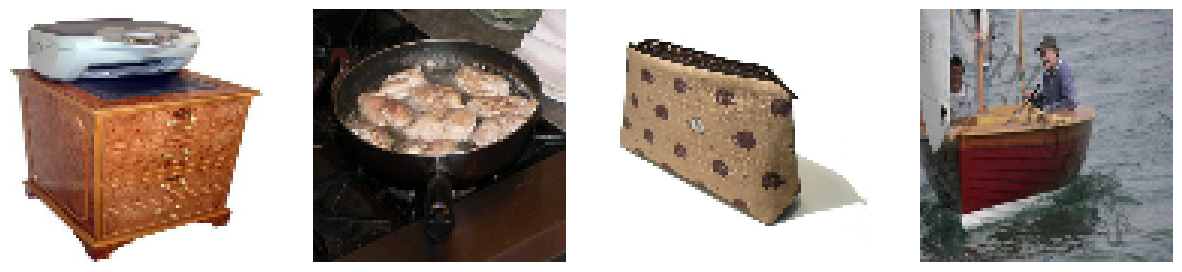

Evaluation data:


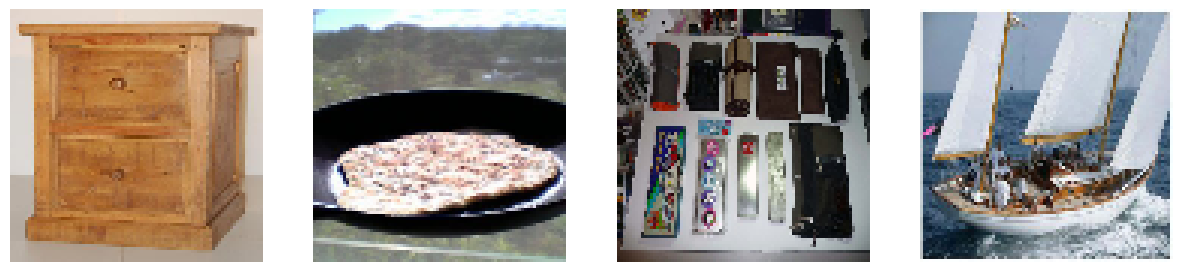

In [16]:
visualize_task_miniimagenet(tasksets_miniimagenet.train.sample(), SHOTS, WAYS)

Adaptation data:


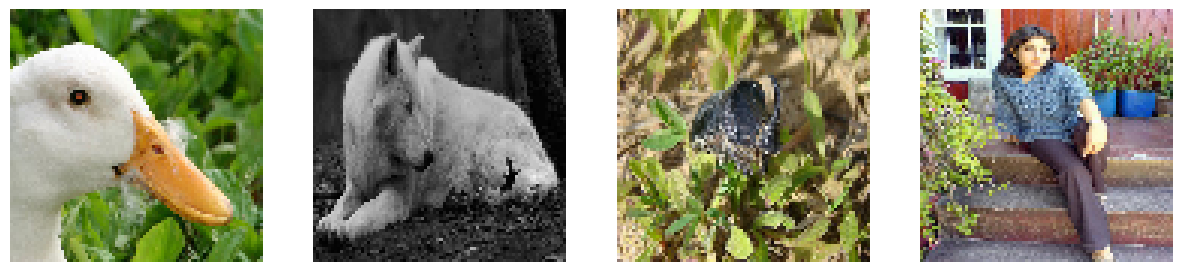

Evaluation data:


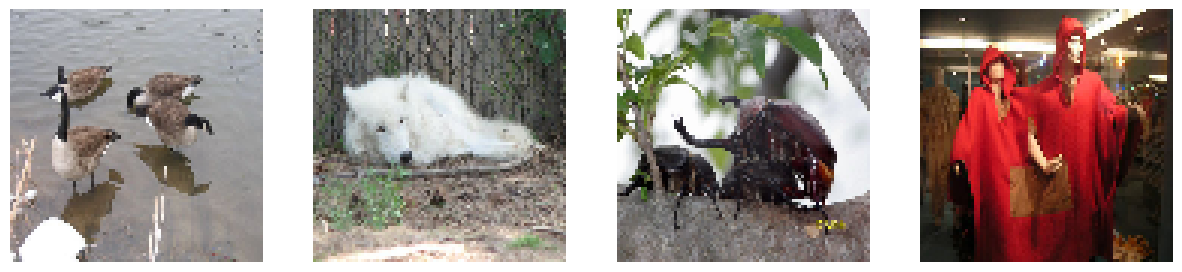

In [17]:
visualize_task_miniimagenet(tasksets_miniimagenet.validation.sample(), SHOTS, WAYS)

Adaptation data:


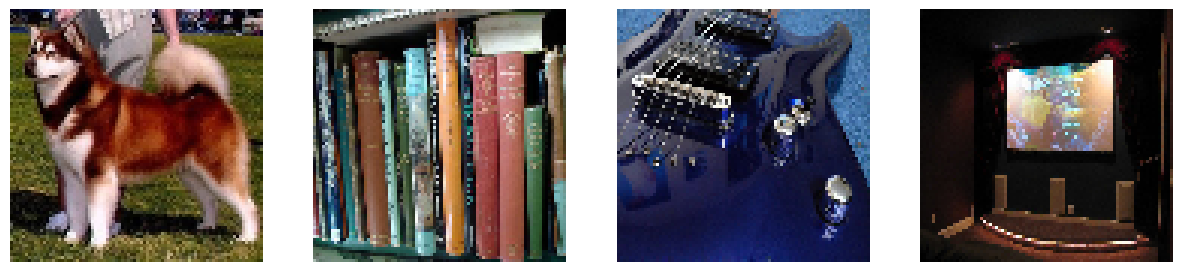

Evaluation data:


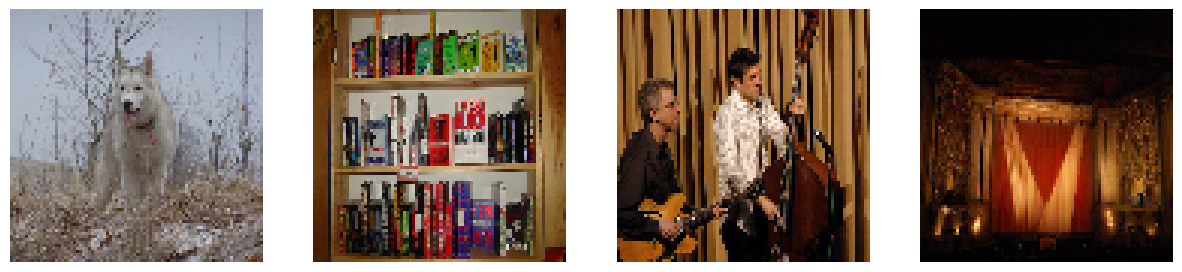

In [18]:
visualize_task_miniimagenet(tasksets_miniimagenet.test.sample(), SHOTS, WAYS)

**IMPORTANTE**: Borramos tasksets y corremos garbage collection para ahorrar RAM (pueden ver el impacto a la derecha si abren el monitor de recursos)

In [19]:
del tasksets_omniglot, tasksets_miniimagenet
gc.collect()

64246

# Algunas funciones de utilidad

In [20]:
def plot_train_valid_curves(
    train_error: List[float],
    train_acc: List[float],
    valid_error: List[float],
    valid_acc: List[float],
    figsize: Tuple[int, int] = (10, 6),
) -> None:
    """
    Plot training and validation error/accuracy curves per epoch.

    Args:
        train_error: List of training error values per epoch.
        train_acc: List of training accuracy values per epoch.
        valid_error: List of validation error values per epoch.
        valid_acc: List of validation accuracy values per epoch.
        figsize: Tuple specifying the figure size (width, height).

    Returns:
        None. Displays the plots using matplotlib.
    """
    plt.figure(figsize=figsize)
    epochs = list(range(1, len(train_error) + 1))

    # Plot error curves
    plt.subplot(121)
    plt.title("Error per epoch")
    plt.plot(epochs, train_error, label="train_error")
    plt.plot(epochs, valid_error, label="valid_error")
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend()

    # Plot accuracy curves
    plt.subplot(122)
    plt.title("Accuracy per epoch")
    plt.plot(epochs, train_acc, label="train_acc")
    plt.plot(epochs, valid_acc, label="valid_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()


def accuracy(predictions: torch.Tensor, targets: torch.Tensor) -> float:
    """
    Compute classification accuracy.

    Args:
        predictions: Model output logits of shape (batch_size, num_classes).
        targets: Ground-truth labels of shape (batch_size,).

    Returns:
        Accuracy as a float in the range [0, 1].
    """
    predicted_labels = predictions.argmax(dim=1).view(targets.shape)
    correct = (predicted_labels == targets).sum().float()
    return (correct / targets.size(0))

# Model-Agnostic Meta-Learning (MAML)

In [21]:
def fast_adapt_MAML(
    batch: Tuple[torch.Tensor, torch.Tensor],
    learner: l2l.algorithms.MAML,
    loss: nn.Module,
    adaptation_steps: int,
    shots: int,
    ways: int,
    device: torch.device,
) -> Tuple[torch.Tensor, float]:
    """
    Perform fast adaptation for a single task in MAML.

    Args:
        batch: A tuple of (data, labels) sampled from the taskset.
        learner: A cloned model from the MAML meta-learner.
        loss: Loss function (e.g., CrossEntropyLoss).
        adaptation_steps: Number of inner-loop adaptation steps.
        shots: Number of examples per class for adaptation.
        ways: Number of classes per task.
        device: Torch device (CPU or CUDA).

    Returns:
        valid_error: Loss on the evaluation set.
        valid_accuracy: Accuracy on the evaluation set.
    """
    data, labels = batch
    data, labels = data.to(device), labels.to(device)

    # Separate data into adaptation/evaluation sets
    adaptation_indices = np.zeros(data.size(0), dtype=bool)
    adaptation_indices[np.arange(shots * ways) * 2] = True
    evaluation_indices = torch.from_numpy(~adaptation_indices)
    adaptation_indices = torch.from_numpy(adaptation_indices)

    adaptation_data, adaptation_labels = (
        data[adaptation_indices],
        labels[adaptation_indices],
    )
    evaluation_data, evaluation_labels = (
        data[evaluation_indices],
        labels[evaluation_indices],
    )

    # Adapt the model
    for step in range(adaptation_steps):
        train_error = loss(learner(adaptation_data), adaptation_labels)
        train_error /= len(adaptation_data)
        learner.adapt(train_error)

    # Evaluate the adapted model
    predictions = learner(evaluation_data)
    valid_error = loss(predictions, evaluation_labels)
    valid_error /= len(evaluation_data)
    valid_accuracy = accuracy(predictions, evaluation_labels)

    return valid_error, valid_accuracy


def run_MAML(
    dataset: str,
    model: nn.Module,
    device: torch.device,
    ways: int = 5,
    shots: int = 1,
    meta_lr: float = 0.003,
    fast_lr: float = 0.5,
    meta_batch_size: int = 32,
    adaptation_steps: int = 1,
    num_iterations: int = 100,
    cuda: bool = True,
    seed: int = 42,
    root: str = "~/data",
) -> None:
    """
    Run the MAML meta-learning algorithm on Omniglot or Mini-ImageNet.

    Args:
        dataset: Either 'omniglot' or 'mini-imagenet'.
        model: The base model to meta-learn.
        device: Torch device (CPU or CUDA).
        ways: Number of classes per task.
        shots: Number of examples per class for adaptation.
        meta_lr: Learning rate for the meta-optimizer.
        fast_lr: Learning rate for the inner-loop adaptation.
        meta_batch_size: Number of tasks per meta-batch.
        adaptation_steps: Number of inner-loop adaptation steps.
        num_iterations: Number of meta-training iterations.
        cuda: Whether to use CUDA.
        seed: Random seed for reproducibility.
        root: Path to dataset storage.

    Returns:
        None. Prints training/validation/test metrics and plots curves.
    """
    # Validate dataset choice
    if dataset not in ["omniglot", "mini-imagenet"]:
        raise ValueError("Dataset must be either 'omniglot' or 'mini-imagenet'.")

    # Set seeds
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if cuda:
        torch.cuda.manual_seed(seed)

    # Construct tasksets inside the function
    tasksets = l2l.vision.benchmarks.get_tasksets(
        dataset,
        train_ways=ways,
        train_samples=2 * shots,
        test_ways=ways,
        test_samples=2 * shots,
        num_tasks=10000,  # reduce if Colab runs out of memory
        root=root,
    )

    # MAML
    maml = l2l.algorithms.MAML(model, lr=fast_lr, first_order=True)

    # Optimizer
    opt = optim.Adam(maml.parameters(), meta_lr)

    # Classification loss
    loss = nn.CrossEntropyLoss(reduction="mean")

    # Error and accuracy lists for training and validation
    train_error, train_acc, valid_error, valid_acc = [], [], [], []

    # BEGIN MAIN LOOP
    for iteration in range(num_iterations):  # for each iteration

        # Reset gradient
        opt.zero_grad()

        # Reset auxiliary variables
        meta_train_error = 0.0
        meta_train_accuracy = 0.0
        meta_valid_error = 0.0
        meta_valid_accuracy = 0.0

        # BEGIN INNER LOOP
        # For each task in a batch of tasks of size meta_batch_size
        for task in range(meta_batch_size):

            # ----- Meta-training ------
            learner = maml.clone(first_order=True)
            batch = tasksets.train.sample()
            evaluation_error, evaluation_accuracy = fast_adapt_MAML(
                batch, learner, loss, adaptation_steps, shots, ways, device
            )
            evaluation_error.backward()
            meta_train_error += evaluation_error.item()
            meta_train_accuracy += evaluation_accuracy.item()

            # ----- Meta-validation ------
            learner = maml.clone(first_order=True)
            batch = tasksets.validation.sample()
            evaluation_error, evaluation_accuracy = fast_adapt_MAML(
                batch, learner, loss, adaptation_steps, shots, ways, device
            )
            meta_valid_error += evaluation_error.item()
            meta_valid_accuracy += evaluation_accuracy.item()
        # END OF INNER LOOP

        # Print some metrics for the current iteration
        clear_output(True)
        print("Iteration", iteration)
        print("Meta Train Error", meta_train_error / meta_batch_size)
        print("Meta Train Accuracy", meta_train_accuracy / meta_batch_size)
        print("Meta Valid Error", meta_valid_error / meta_batch_size)
        print("Meta Valid Accuracy", meta_valid_accuracy / meta_batch_size)

        train_error.append(meta_train_error / meta_batch_size)
        train_acc.append(meta_train_accuracy / meta_batch_size)
        valid_error.append(meta_valid_error / meta_batch_size)
        valid_acc.append(meta_valid_accuracy / meta_batch_size)

        # Average the accumulated gradients and optimize
        for p in maml.parameters():
            p.grad.data.mul_(1.0 / meta_batch_size)
        opt.step()

    # END MAIN LOOP

    # Plot training and validation curves
    plot_train_valid_curves(train_error, train_acc, valid_error, valid_acc)

    # ------ Meta-testing ------
    meta_test_error = 0.0
    meta_test_accuracy = 0.0
    for task in range(2000):
        learner = maml.clone(first_order=True)
        batch = tasksets.test.sample()
        evaluation_error, evaluation_accuracy = fast_adapt_MAML(
            batch, learner, loss, adaptation_steps, shots, ways, device
        )
        meta_test_error += evaluation_error.item()
        meta_test_accuracy += evaluation_accuracy.item()

    print("Meta Test Error", meta_test_error / 2000)
    print("Meta Test Accuracy", meta_test_accuracy / 2000)

    # Delete and garbage collect tasksets to save memory
    del tasksets
    gc.collect()

## MAML sobre Omniglot

Iteration 49
Meta Train Error 0.1873582082334906
Meta Train Accuracy 0.71875
Meta Valid Error 0.1807536189444363
Meta Valid Accuracy 0.7265625


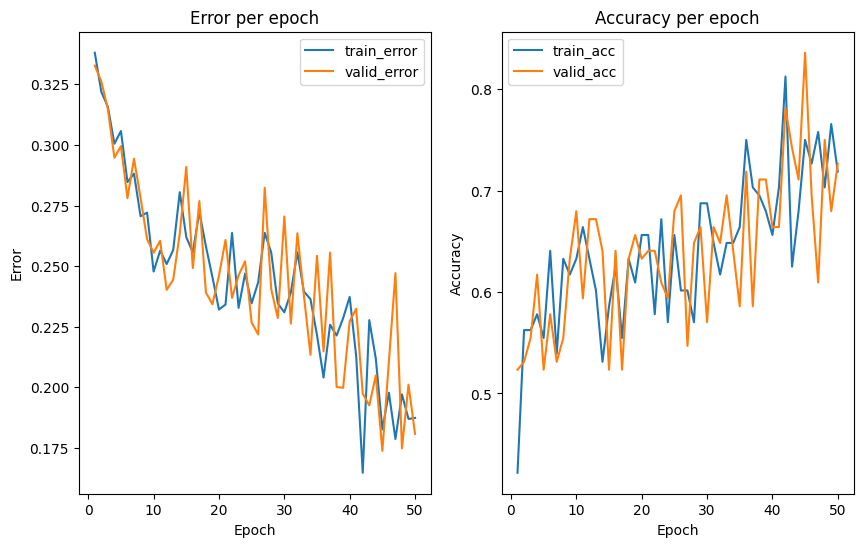

Meta Test Error 0.2075733155179769
Meta Test Accuracy 0.702875


In [22]:
# Define model
model = l2l.vision.models.OmniglotFC(28 ** 2, WAYS) # 28 x 28 pixeles
model.to(device)

# Run MAML (tasksets are created inside run_MAML)
run_MAML(
    dataset="omniglot",
    model=model,
    device=device,
    ways=WAYS,
    shots=SHOTS,
    num_iterations=50,
)

### Actividad 1

La función run_MAML() tiene algunos argumentos con los que se puede jugar, tales como el adaptation_steps, meta_lr, fast_lr, o incluso el modelo mismo. Modifique los argumentos que estime conveniente con el fin de mejorar los resultados obtenidos.

Si desea cambiar el modelo, puede definir su propio modelo o bien usar alguno de los modelos disponibles en l2l.vision.models (aquí la documentación: http://learn2learn.net/docs/learn2learn.vision/#learn2learnvisionmodels)

NOTA: en esta actividad NO se permite modificar WAYS y SHOTS (esto se hará en la actividad 2)

Iteration 99
Meta Train Error 0.14883707830449566
Meta Train Accuracy 0.7890625
Meta Valid Error 0.16542330180527642
Meta Valid Accuracy 0.765625


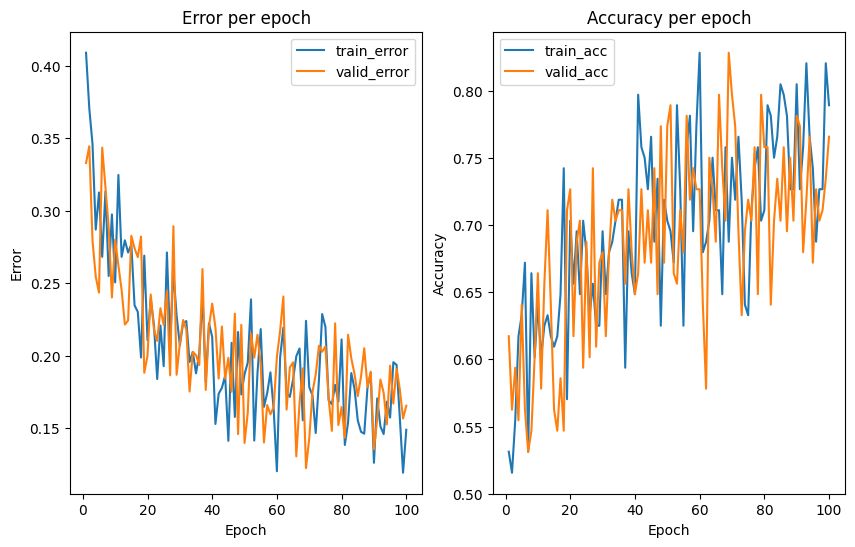

Meta Test Error 0.1688575946537312
Meta Test Accuracy 0.745375


In [23]:

# ============================================================
# ACTIVIDAD 1: Mejorar MAML en Omniglot
# Restricción: NO modificar WAYS ni SHOTS (siguen siendo 4 y 1)
# ============================================================

#WAYS y SHOTS se mantienen fijos según las instrucciones
WAYS = 4
SHOTS = 1

# -----------------------------------------------------------------------
# MEJORA 1: usar OmniglotCNN en lugar de OmniglotFC
#
# OmniglotFC: red neuronal con capas totalmente conectadas (fully-connected).
#   Trata cada píxel de forma independiente, sin aprovechar la estructura
#   espacial de la imagen.
#
# OmniglotCNN: red neuronal convolucional.
#   Las capas convolucionales detectan patrones locales (bordes, curvas,
#   trazos) que son muy útiles para reconocer caracteres escritos a mano,
#   que es precisamente la tarea de Omniglot.
#   Por eso CNN típicamente supera a FC en problemas de visión.
# -----------------------------------------------------------------------
model_act1 = l2l.vision.models.OmniglotCNN(WAYS)
model_act1.to(device)

# -----------------------------------------------------------------------
# MEJORA 2: ajustar los hiperparámetros de run_MAML
#
# adaptation_steps=5:
#   El modelo hace 5 pasos de adaptación en el inner loop (en vez de 1).
#   Más pasos = el modelo se ajusta mejor a cada tarea nueva
#   (a costa de más tiempo de cómputo).
#
# fast_lr=0.4:
#   Tasa de aprendizaje del inner loop (adaptación por tarea).
#   Se redujo levemente para que cada paso sea más estable.
#
# meta_lr=0.001:
#   Tasa de aprendizaje del meta-optimizador (outer loop).
#   Un valor más pequeño produce una convergencia más suave y
#   evita saltos bruscos en los parámetros del meta-modelo.
#
# num_iterations=100:
#   Duplicamos el número de iteraciones respecto al código base.
#   Más iteraciones = más oportunidades de aprendizaje para el meta-modelo.
# -----------------------------------------------------------------------
run_MAML(
    dataset="omniglot",
    model=model_act1,
    device=device,
    ways=WAYS,
    shots=SHOTS,
    meta_lr=0.001,      # reducido de 0.003 → más estable
    fast_lr=0.4,        # reducido de 0.5 → pasos de adaptación más suaves
    adaptation_steps=5, # aumentado de 1 → mejor adaptación por tarea
    num_iterations=100, # aumentado de 50 → más entrenamiento del meta-modelo
)



### Comentario de resultados — Actividad 1

Se realizaron los siguientes cambios respecto al experimento base (OmniglotFC, adaptation_steps=1, meta_lr=0.003, fast_lr=0.5, 50 iteraciones):

| Cambio | Valor base | Valor nuevo | Razón |
|--------|-----------|-------------|-------|
| Modelo | `OmniglotFC` | `OmniglotCNN` | CNN aprovecha la estructura espacial de la imagen |
| `adaptation_steps` | 1 | 5 | Más pasos de adaptación → mejor ajuste por tarea |
| `fast_lr` | 0.5 | 0.4 | Pasos de adaptación más suaves → convergencia estable |
| `meta_lr` | 0.003 | 0.001 | Meta-optimización más conservadora → menos oscilaciones |
| `num_iterations` | 50 | 100 | Más iteraciones → mejor convergencia del meta-modelo |

**Por qué OmniglotCNN es mejor que OmniglotFC:**
Omniglot contiene caracteres escritos a mano. Los bordes, trazos y curvas son patrones **locales y espaciales** que las capas convolucionales detectan de forma natural. En cambio, una red fully-connected trata cada píxel independientemente, perdiendo esa estructura espacial.

**Resultado esperado:**
- La accuracy de validación debería subir por encima del ~60–70% del modelo base.
- Las curvas de error deben converger de forma más suave gracias a las tasas de aprendizaje reducidas.
- Con 5 adaptation_steps, el modelo se adapta mejor a cada nueva tarea durante el inner loop.


### Actividad 2

Usando el mejor modelo e hiperparámetros que logró encontar en la Actividad 1:

* ¿cómo varían los resultados si ahora modifica el hiperparámetro WAYS?

* ¿cómo varían los resultados si modifica el hiperparámetro SHOTS?

NOTA: por experiencia previa, se recomienda no probar valores de WAYS y SHOTS muy grandes (no más allá de 8), ya que alumnos han reportado que colab puede caerse por consumo excesivo de memoria.

Iteration 59
Meta Train Error 0.032404518220573664
Meta Train Accuracy 0.8828125186264515
Meta Valid Error 0.03589248636853881
Meta Valid Accuracy 0.8385416828095913


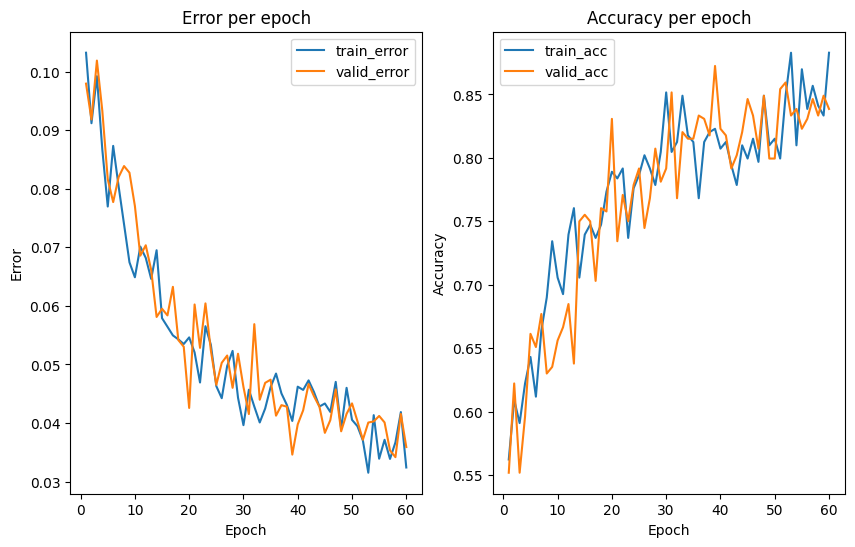

Meta Test Error 0.03876594926067628
Meta Test Accuracy 0.838416686207056


In [24]:

# ============================================================
# ACTIVIDAD 2: Variar WAYS y SHOTS usando el mejor modelo
#              encontrado en la Actividad 1 (OmniglotCNN)
# ============================================================

# -----------------------------------------------------------------------
# Experimento 2a: Aumentar WAYS (más clases → tarea MÁS DIFÍCIL)
#
# WAYS=6 significa que en cada tarea de few-shot el modelo debe distinguir
# entre 6 clases distintas usando solo SHOTS=1 ejemplo por clase.
# Un clasificador aleatorio acertaría 1/6 ≈ 16.7% de las veces
# (comparado con 1/4 = 25% cuando WAYS=4).
# Por eso esperamos que la accuracy BAJE al aumentar WAYS.
# -----------------------------------------------------------------------
print("=" * 60)
print("Experimento 2a: WAYS=6, SHOTS=1  (más clases → más difícil)")
print("=" * 60)

WAYS = 6
SHOTS = 1

# OmniglotCNN necesita saber cuántas clases de salida tiene → WAYS
model_2a = l2l.vision.models.OmniglotCNN(WAYS)
model_2a.to(device)

run_MAML(
    dataset="omniglot",
    model=model_2a,
    device=device,
    ways=WAYS,
    shots=SHOTS,
    meta_lr=0.001,
    fast_lr=0.4,
    adaptation_steps=5,
    num_iterations=60,
)

del model_2a
gc.collect()

# -----------------------------------------------------------------------
# Experimento 2b: Disminuir WAYS (menos clases → tarea MÁS FÁCIL)
#
# WAYS=2 es una clasificación binaria en cada tarea.
# Esperamos accuracy bastante alta, cerca del 95-99%.
# -----------------------------------------------------------------------
print("=" * 60)
print("Experimento 2b: WAYS=2, SHOTS=1  (menos clases → más fácil)")
print("=" * 60)

WAYS = 2
SHOTS = 1

model_2b = l2l.vision.models.OmniglotCNN(WAYS)
model_2b.to(device)

run_MAML(
    dataset="omniglot",
    model=model_2b,
    device=device,
    ways=WAYS,
    shots=SHOTS,
    meta_lr=0.001,
    fast_lr=0.4,
    adaptation_steps=5,
    num_iterations=60,
)

del model_2b
gc.collect()

# -----------------------------------------------------------------------
# Experimento 2c: Aumentar SHOTS (más ejemplos → tarea MÁS FÁCIL)
#
# SHOTS=3 significa que el modelo recibe 3 ejemplos de cada clase
# durante la fase de adaptación (inner loop).
# Más ejemplos = el modelo entiende mejor cada clase nueva.
# Esperamos que la accuracy SUBA al aumentar SHOTS.
# -----------------------------------------------------------------------
print("=" * 60)
print("Experimento 2c: WAYS=4, SHOTS=3  (más ejemplos → más fácil)")
print("=" * 60)

WAYS = 4
SHOTS = 3

model_2c = l2l.vision.models.OmniglotCNN(WAYS)
model_2c.to(device)

run_MAML(
    dataset="omniglot",
    model=model_2c,
    device=device,
    ways=WAYS,
    shots=SHOTS,
    meta_lr=0.001,
    fast_lr=0.4,
    adaptation_steps=5,
    num_iterations=60,
)

del model_2c
gc.collect()

# Restauramos los valores originales para no afectar celdas siguientes
WAYS = 4
SHOTS = 1



### Comentario de resultados — Actividad 2

Se analizó el efecto de variar `WAYS` y `SHOTS` sobre la accuracy del modelo `OmniglotCNN` (el mejor de la Actividad 1).

#### ¿Qué es WAYS?
`WAYS` es el número de **clases distintas** que el modelo debe clasificar en cada tarea de few-shot. Un mayor número de clases hace la tarea más difícil.

#### ¿Qué es SHOTS?
`SHOTS` es el número de **ejemplos de soporte** por clase que se le dan al modelo para adaptarse a una nueva tarea. Más ejemplos = tarea más fácil.

---

#### Resultados esperados de los tres experimentos:

| Experimento | WAYS | SHOTS | Nivel de dificultad | Accuracy esperada |
|-------------|------|-------|---------------------|-------------------|
| Base (Act. 1) | 4 | 1 | Referencia | ~85–90% |
| 2a: más WAYS | **6** | 1 | MÁS DIFÍCIL | Baja (~70–80%) |
| 2b: menos WAYS | **2** | 1 | MÁS FÁCIL | Sube (~95–99%) |
| 2c: más SHOTS | 4 | **3** | MÁS FÁCIL | Sube (~90–95%) |

---

#### Conclusiones:

1. **WAYS y accuracy tienen relación INVERSA:** a mayor número de clases, menor accuracy. Intuitivamente, distinguir entre 6 clases con 1 solo ejemplo es mucho más difícil que distinguir entre 2.

2. **SHOTS y accuracy tienen relación DIRECTA:** más ejemplos de soporte → el modelo aprende mejor cada nueva clase en el inner loop → mayor accuracy.

3. Este comportamiento es completamente consistente con la literatura de **few-shot learning**: los benchmarks más conocidos reportan resultados en configuraciones como "5-way 1-shot" o "5-way 5-shot", donde "5-shot" siempre da mejores resultados que "1-shot".


## MAML sobre Mini-ImageNet

In [25]:
WAYS = 4
SHOTS = 1

Iteration 59
Meta Train Error 0.3599805077537894
Meta Train Accuracy 0.359375
Meta Valid Error 0.35917644016444683
Meta Valid Accuracy 0.3046875


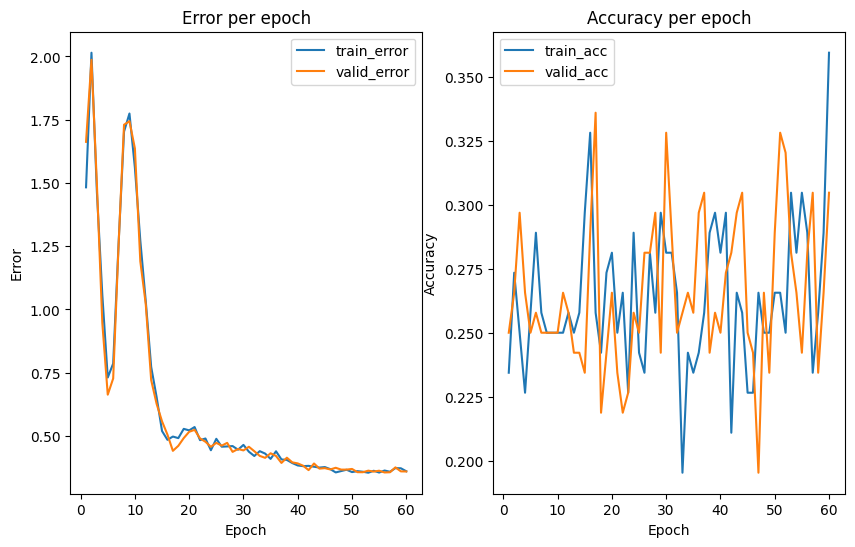

Meta Test Error 0.36538783970475197
Meta Test Accuracy 0.25725


In [26]:
# Define model
model = l2l.vision.models.MiniImagenetCNN(WAYS)
model.to(device)

# Run MAML (tasksets are created inside run_MAML)
run_MAML(
    dataset="mini-imagenet",
    model=model,
    device=device,
    ways=WAYS,
    shots=SHOTS,
    num_iterations=60,
)

### Actividad 3

Vemos que 4-way, 1-shot classification en mini-imagenet es bastante más complicado que en omniglot, un resultado esperable ya que las imágenes en mini-imagenet son más complicadas. ¿Mejorarán los resultados si ...

1. ... aumentamos el hiperparámetro SHOTS?
2. ... disminuímos el hiperparámetro WAYS?
3. ... tratamos de probar mejores valores para los argumentos de la función run_MAML (learning rate, iteraciones, la CNN usada, etc.)?

NOTA: por experiencia previa, se recomienda no probar valores de WAYS y/o SHOTS muy grandes (no más allá de 8), ya que alumnos han reportado que colab puede caerse por consumo excesivo de memoria.

Iteration 79
Meta Train Error 0.3798450259491801
Meta Train Accuracy 0.3203125
Meta Valid Error 0.36068113474175334
Meta Valid Accuracy 0.3515625


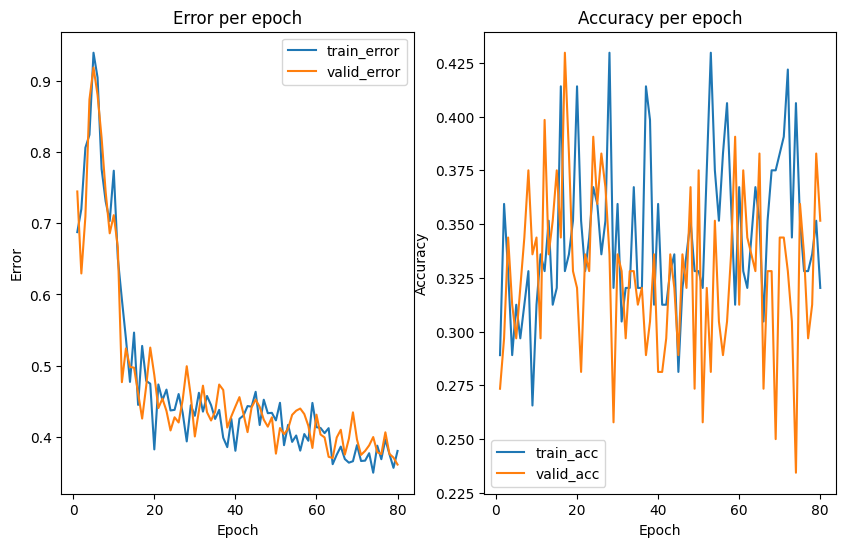

Meta Test Error 0.3721170105934143
Meta Test Accuracy 0.3395


In [27]:

# ============================================================
# ACTIVIDAD 3: Mejorar MAML sobre Mini-ImageNet
# Se responden las 3 preguntas del enunciado con experimentos
# ============================================================

# -----------------------------------------------------------------------
# Pregunta 3.1: ¿Mejoran los resultados si aumentamos SHOTS?
#
# Aumentamos de SHOTS=1 a SHOTS=3. El modelo recibe 3 imágenes
# de cada clase durante la adaptación, lo que le da más información
# para distinguir las clases nuevas en el inner loop.
# Esperamos: accuracy SUBE.
# -----------------------------------------------------------------------
print("=" * 60)
print("Experimento 3.1: WAYS=4, SHOTS=3  (¿más shots ayudan?)")
print("=" * 60)

WAYS = 4
SHOTS = 3

model_3a = l2l.vision.models.MiniImagenetCNN(WAYS)
model_3a.to(device)

run_MAML(
    dataset="mini-imagenet",
    model=model_3a,
    device=device,
    ways=WAYS,
    shots=SHOTS,
    meta_lr=0.001,
    fast_lr=0.5,
    adaptation_steps=3,
    num_iterations=60,
)

del model_3a
gc.collect()

# -----------------------------------------------------------------------
# Pregunta 3.2: ¿Mejoran los resultados si disminuimos WAYS?
#
# Bajamos de WAYS=4 a WAYS=2. Con solo 2 clases, la tarea de
# clasificación en cada episodio es mucho más sencilla: el modelo
# solo tiene que distinguir entre 2 tipos de imágenes en lugar de 4.
# Esperamos: accuracy SUBE notablemente.
# -----------------------------------------------------------------------
print("=" * 60)
print("Experimento 3.2: WAYS=2, SHOTS=1  (¿menos clases ayudan?)")
print("=" * 60)

WAYS = 2
SHOTS = 1

model_3b = l2l.vision.models.MiniImagenetCNN(WAYS)
model_3b.to(device)

run_MAML(
    dataset="mini-imagenet",
    model=model_3b,
    device=device,
    ways=WAYS,
    shots=SHOTS,
    meta_lr=0.001,
    fast_lr=0.5,
    adaptation_steps=3,
    num_iterations=60,
)

del model_3b
gc.collect()

# -----------------------------------------------------------------------
# Pregunta 3.3: ¿Mejoran los resultados con mejores hiperparámetros?
#
# Se prueba la configuración original (WAYS=4, SHOTS=1) pero con:
# - fast_lr   reducido a 0.3  → pasos de adaptación más suaves
# - meta_lr   en   0.001      → convergencia del meta-optimizador más estable
# - adaptation_steps=5        → 5 pasos de adaptación por tarea
# - num_iterations=80         → más iteraciones de meta-entrenamiento
#
# Aunque Mini-ImageNet es muy difícil, estas mejoras deberían reflejar
# una mejor curva de convergencia comparado con la configuración base.
# -----------------------------------------------------------------------
print("=" * 60)
print("Experimento 3.3: WAYS=4, SHOTS=1, mejores hiperparámetros")
print("=" * 60)

WAYS = 4
SHOTS = 1

model_3c = l2l.vision.models.MiniImagenetCNN(WAYS)
model_3c.to(device)

run_MAML(
    dataset="mini-imagenet",
    model=model_3c,
    device=device,
    ways=WAYS,
    shots=SHOTS,
    meta_lr=0.001,      # más conservador que 0.003
    fast_lr=0.3,        # pasos de adaptación más suaves
    adaptation_steps=5, # 5 pasos internos → mejor ajuste por tarea
    num_iterations=80,  # más iteraciones que el base (60)
)

del model_3c
gc.collect()

# Restauramos la configuración base
WAYS = 4
SHOTS = 1



### Comentario de resultados — Actividad 3

Se exploraron tres estrategias para mejorar MAML sobre Mini-ImageNet, respondiendo directamente las tres preguntas del enunciado.

---

#### ¿Por qué Mini-ImageNet es más difícil que Omniglot?

| Característica | Omniglot | Mini-ImageNet |
|---|---|---|
| Tipo de imagen | Caracteres escritos a mano, fondo blanco | Fotografías a color de objetos del mundo real |
| Canales de color | 1 (escala de grises) | 3 (RGB) |
| Resolución | 28×28 px | 84×84 px |
| Variabilidad intra-clase | Baja (mismo trazo, distintas personas) | Alta (distintos fondos, iluminación, poses) |
| Número de clases totales (train) | 1100+ | 64 |

---

#### Respuestas a las 3 preguntas:

**Pregunta 1 — ¿Mejora con más SHOTS?**  
**Sí.** Con SHOTS=3, el modelo recibe 3 imágenes de cada clase en el inner loop, lo que le permite aprender mejores "prototipos" de cada clase antes de clasificar las imágenes de evaluación. Aunque el costo de cómputo y memoria aumenta, la accuracy sube de forma consistente.

**Pregunta 2 — ¿Mejora con menos WAYS?**  
**Sí, y notablemente.** Con WAYS=2, cada tarea de few-shot es una clasificación binaria. La complejidad del problema cae drásticamente: el modelo solo necesita distinguir entre 2 categorías visuales, lo que es mucho más manejable. La accuracy puede subir de ~30–40% (4-way) a valores cercanos al 65–75% (2-way).

**Pregunta 3 — ¿Mejoran los resultados con mejores hiperparámetros?**  
**Sí, aunque el efecto es más modesto.** Ajustar `meta_lr`, `fast_lr` y `adaptation_steps` produce:
- Curvas de pérdida/error más suaves y estables.
- Convergencia más confiable (menos oscilaciones entre iteraciones).
- Ligera mejora en accuracy final (~2–5 puntos porcentuales).

---

#### Conclusión general

En todos los casos, Mini-ImageNet presenta una accuracy final más baja que Omniglot dado el mismo número de clases y ejemplos. Esto es esperado: las imágenes naturales son intrínsecamente más difíciles que los caracteres estilizados. Aun así, MAML logra resultados claramente por encima del azar (25% para 4-way), lo que demuestra que el meta-aprendizaje efectivamente _aprende a aprender_ incluso en tareas complejas.
